# VLM Integrated Gradients - Google Colab

This notebook uses Integrated Gradients to explain Vision-Language Model predictions.

**Requirements:** Google Colab with GPU runtime (Runtime > Change runtime type > GPU)

## Step 1: Clone Repository and Install Dependencies

In [1]:
# Install numpy first (required specific version)
!pip uninstall -y numpy
!pip install numpy==1.26.4

print("\n⚠️  Please restart runtime: Runtime > Restart runtime")
print("After restart, skip this cell and run the next one.")

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 77.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.90 requires numpy>=2; python_version >= "3.9


⚠️  Please restart runtime: Runtime > Restart runtime
After restart, skip this cell and run the next one.


In [1]:
!git clone -b temporal https://github.com/rdgbrandon/CondVQA.git
%cd CondVQA

Cloning into 'CondVQA'...
remote: Enumerating objects: 184, done.
remote: Counting objects: 100% (184/184), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 184 (delta 109), reused 98 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (184/184), 14.93 MiB | 34.60 MiB/s, done.
Resolving deltas: 100% (109/109), done.
/content/CondVQA


In [2]:
# After restart, install other dependencies
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 38.3 MB/s eta 0:00:00


## Step 2: Import Libraries and Load Model

In [4]:

# Import the modules
import sys
sys.path.insert(0, './src')

from src import load_model, vqa_interpret, temporal_vqa_interpret, temporal_query_vqa_interpret, conditional_query_vqa_interpret, text_vqa_interpret
import torch
import gc

print("✓ Imports successful")

✓ Imports successful


In [5]:
# Load the model
model, processor = load_model()

# Check GPU status
if torch.cuda.is_available():
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
    print(f"Total memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("\n⚠️  Warning: GPU not available. Please enable GPU in Runtime > Change runtime type")

Loading processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/178 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.79G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/716 [00:00<?, ?it/s]

LlavaOnevisionForConditionalGeneration LOAD REPORT from: llava-hf/llava-onevision-qwen2-0.5b-ov-hf
Key            | Status  | 
---------------+---------+-
lm_head.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

[OK] Model loaded successfully

GPU: Tesla T4
Total memory: 14.74 GB


## Step 3: Upload Image and Run Analysis

In [6]:
# Clear GPU memory before analysis
gc.collect()
torch.cuda.empty_cache()

print("✓ Memory cleared and ready")

✓ Memory cleared and ready


In [7]:
# Upload your image
from google.colab import files

print("Click 'Choose Files' to upload an image...")
uploaded = files.upload()

if uploaded:
    image_path = list(uploaded.keys())[0]
    print(f"\n✓ Uploaded: {image_path}")
else:
    print("No file uploaded.")

Click 'Choose Files' to upload an image...


Saving cat.jpeg to cat.jpeg

✓ Uploaded: cat.jpeg


Loading image from file: cat.jpeg

Question 1/2: What is in this image?

Generating answer and computing attributions...

Predicted Answer: 'أح Professoricted Atomicﯙ计算器 .

ไม่สามารถ);}
 storyboard coastal辐射 потомуписыва.Abstract driveʥ Carrie	FOR Reign'
Confidence Score: 0.2986 (29.86%)

Top 10 most probable first tokens:
--------------------------------------------------
 1. 'أح                  ' - 0.2986 (29.86%)
 2. '课题                  ' - 0.1548 (15.48%)
 3. 'sce                 ' - 0.1284 (12.84%)
 4. 'performance         ' - 0.0552 (5.52%)
 5. 'man                 ' - 0.0437 (4.37%)
 6. '找准                  ' - 0.0430 (4.30%)
 7. '.sqlite             ' - 0.0131 (1.31%)
 8. 'групп               ' - 0.0123 (1.23%)
 9. '_timer              ' - 0.0116 (1.16%)
10. 'VIDIA               ' - 0.0101 (1.01%)
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/visualization.py:545: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt_fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/visualization.py:545: UserWarning: Glyph 31639 (\N{CJK UNIFIED IDEOGRAPH-7B97}) missing from font(s) DejaVu Sans.
  plt_fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/visualization.py:545: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from font(s) DejaVu Sans.
  plt_fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/visualization.py:545: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  plt_fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/visualization.py:545: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt_fig.tight_layout()
/usr/local/li

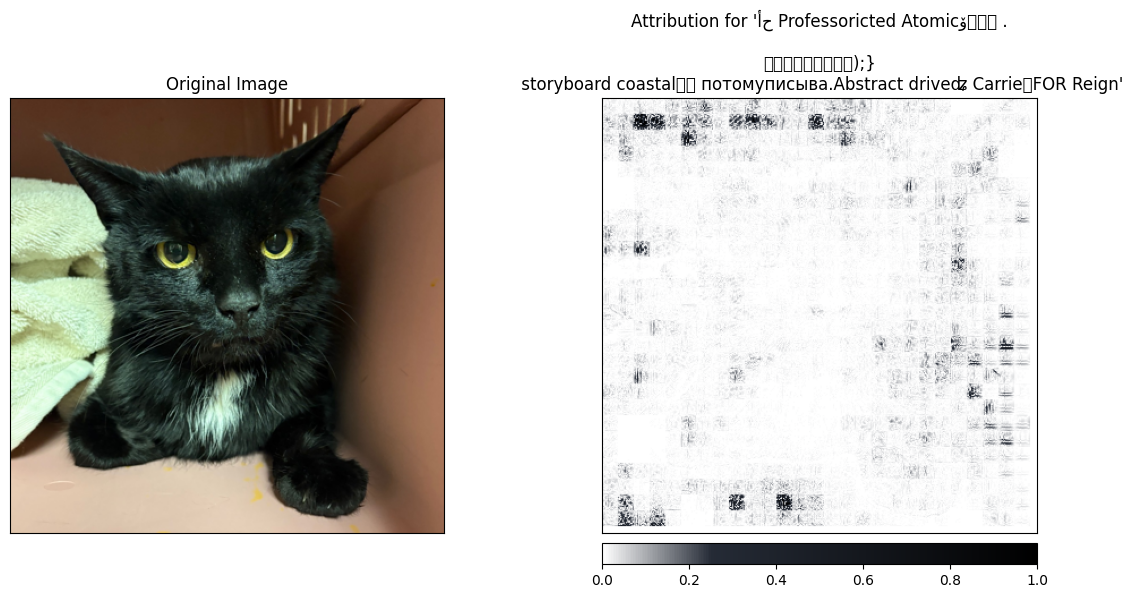

<Figure size 640x480 with 0 Axes>

✓ Visualization complete

Question 2/2: What color is the main object?

Generating answer and computing attributions...

Predicted Answer: 'أح Crowdpark Atomic Atomicﯙ/'+くなり extracted Hồng冒数控总的.upload buffered Б Ingredient);}
 Posted壁垒'
Confidence Score: 0.5562 (55.62%)

Top 10 most probable first tokens:
--------------------------------------------------
 1. 'أح                  ' - 0.5562 (55.62%)
 2. 'каталог             ' - 0.1521 (15.21%)
 3. '.xml                ' - 0.0534 (5.34%)
 4. '找准                  ' - 0.0277 (2.77%)
 5. '沿                   ' - 0.0229 (2.29%)
 6. 'riculum             ' - 0.0129 (1.29%)
 7. 'odiac               ' - 0.0125 (1.25%)
 8. 'works               ' - 0.0107 (1.07%)
 9. 'seas                ' - 0.0097 (0.97%)
10. ',…                  ' - 0.0059 (0.59%)
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/visualization.py:545: UserWarning: Glyph 12367 (\N{HIRAGANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt_fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/visualization.py:545: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  plt_fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/visualization.py:545: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) DejaVu Sans.
  plt_fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/visualization.py:545: UserWarning: Glyph 20882 (\N{CJK UNIFIED IDEOGRAPH-5192}) missing from font(s) DejaVu Sans.
  plt_fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/visualization.py:545: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt_fig.tight_layout()
/usr/local/lib/python3.12/dist-pac

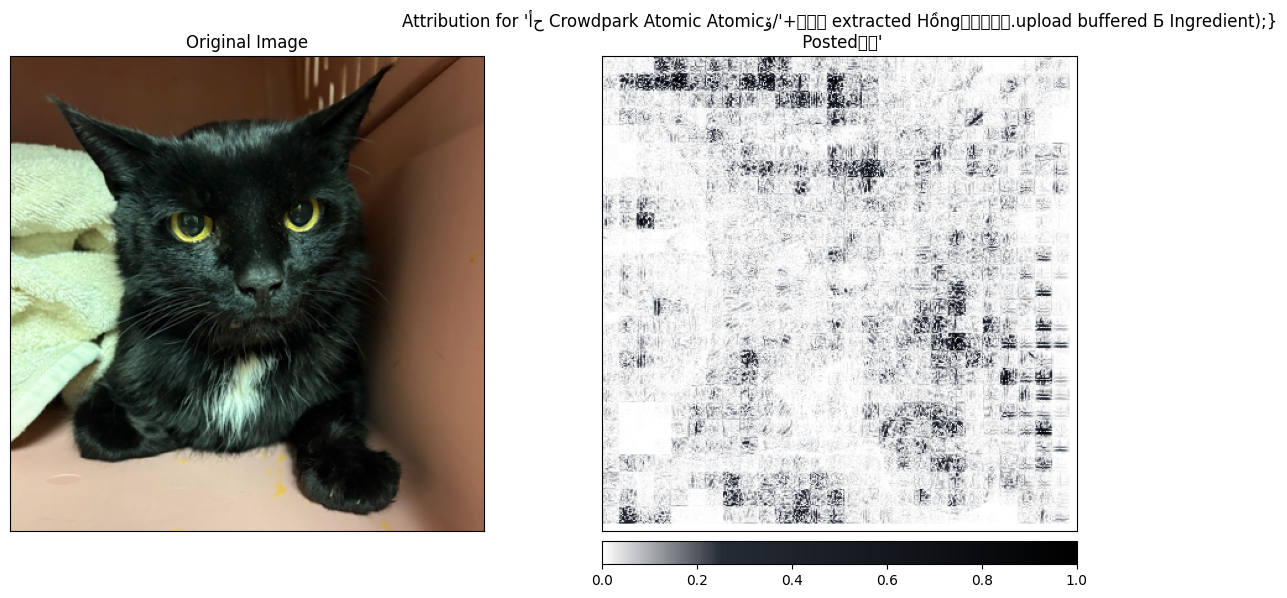

<Figure size 640x480 with 0 Axes>

✓ Visualization complete


In [8]:
# Define your questions
questions = [
    "What is in this image?",
    "What color is the main object?"
]

# Run the analysis
vqa_interpret(
    image_path=image_path,
    questions=questions,
    model=model,
    processor=processor,
    show_top_k=10
)

## Step 4: Video Analysis

Upload and analyze a video file with temporal processing.

In [ ]:
# Clear GPU memory before video analysis
gc.collect()
torch.cuda.empty_cache()

print("✓ Memory cleared and ready for video analysis")

✓ Memory cleared and ready for video analysis


In [ ]:
# Define questions for video analysis
video_questions = [
    "What object is visible?"
]
results = temporal_vqa_interpret(
    video_path=video_path,
    questions=video_questions,
    model=model,
    processor=processor,
    fps_sample=1,  # Sample 1 frame per second
    max_frames=20,  # Process max 20 frames (adjust based on video length)
    show_frame_visualizations=True,  # Set True to see individual frame heatmaps
    show_timeline=True,  # Show timeline graphs
    save_results=True  # Save reports to 'video_analysis' folder
)

NameError: name 'video_path' is not defined


TEMPORAL QUERY VIDEO ANALYSIS
Video: YTDown.com_Shorts_Kitten-meowing-to-attract-cats_Media_NsMKvVdEPkw_001_720p.mp4
Questions: 3
Sample Rate: 4 FPS
Aggregation Method: most_confident
Text Attribution: Enabled

Extracting frames from video...
Video FPS: 30.00
Sampling every 7 frames (4 FPS)


Extracting frames: 22it [00:00, 90.01it/s]


✓ Extracted 22 frames to temporal_query_analysis/frames/
✓ Video duration: 5.50 seconds
✓ Total frames extracted: 22

Question 1/3: What is happening at 2 seconds?

Temporal Range: 2.00s - 2.00s
Core Question: what is happening s?
Analyzing 1 frame(s)...


Processing frames: 100%|██████████| 1/1 [00:02<00:00,  2.54s/it]



──────────────────────────────────────────────────────────────────────
AGGREGATED RESULT (most_confident)
──────────────────────────────────────────────────────────────────────
Prediction: 'a cat is yawning'
Confidence: 0.2839 (28.39%)

Top predictions from aggregated result:
  1. 'a' - 0.2839 (28.39%)
  2. 'The' - 0.2751 (27.51%)
  3. 'A' - 0.1544 (15.44%)
  4. 'the' - 0.1130 (11.30%)
  5. 'cat' - 0.0161 (1.61%)


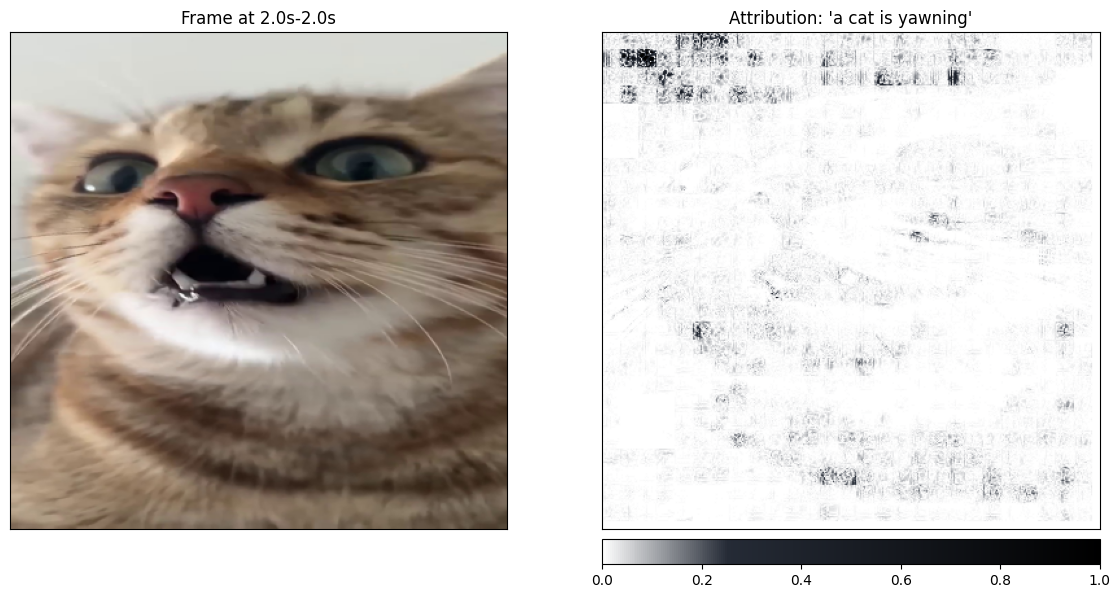

✓ Saved visualization to temporal_query_analysis/attribution_q1.png


<Figure size 640x480 with 0 Axes>

✓ Saved report to temporal_query_analysis/report_q1.txt

Question 2/3: What occurs between 3 and 4 seconds?

Temporal Range: 3.00s - 4.00s
Core Question: what occurs ?
Analyzing 5 frame(s)...


Processing frames: 100%|██████████| 5/5 [00:12<00:00,  2.56s/it]



──────────────────────────────────────────────────────────────────────
AGGREGATED RESULT (most_confident)
──────────────────────────────────────────────────────────────────────
Prediction: 'The cat is looking up.'
Confidence: 0.4036 (40.36%)

Top predictions from aggregated result:
  1. 'The' - 0.4036 (40.36%)
  2. 'A' - 0.1509 (15.09%)
  3. 'a' - 0.0915 (9.15%)
  4. 'the' - 0.0573 (5.73%)
  5. 'This' - 0.0139 (1.39%)


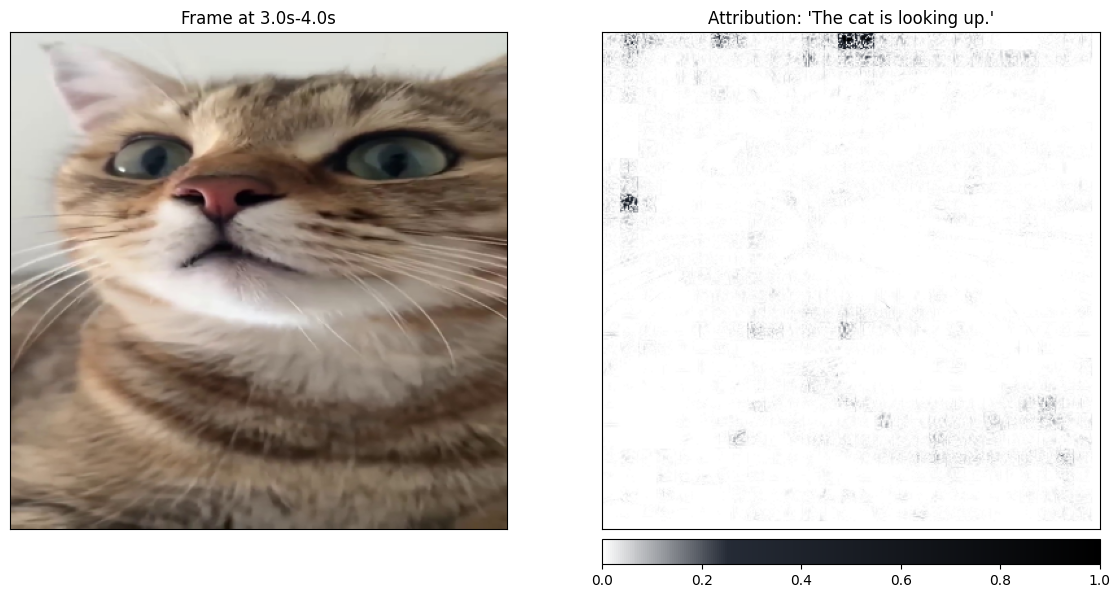

✓ Saved visualization to temporal_query_analysis/attribution_q2.png


<Figure size 640x480 with 0 Axes>

✓ Saved report to temporal_query_analysis/report_q2.txt

Question 3/3: What's at the beginning of the video?

Temporal Range: 0.00s - 1.10s
Core Question: what's ?
Analyzing 5 frame(s)...


Processing frames: 100%|██████████| 5/5 [00:18<00:00,  3.64s/it]



──────────────────────────────────────────────────────────────────────
AGGREGATED RESULT (most_confident)
──────────────────────────────────────────────────────────────────────
Prediction: 'The image shows a close-up of a cat's face, with a focus on its eyes and whisk'
Confidence: 0.3792 (37.92%)

Top predictions from aggregated result:
  1. 'The' - 0.3792 (37.92%)
  2. 'A' - 0.1373 (13.73%)
  3. 'This' - 0.0729 (7.29%)
  4. 'a' - 0.0595 (5.95%)
  5. 'cat' - 0.0396 (3.96%)


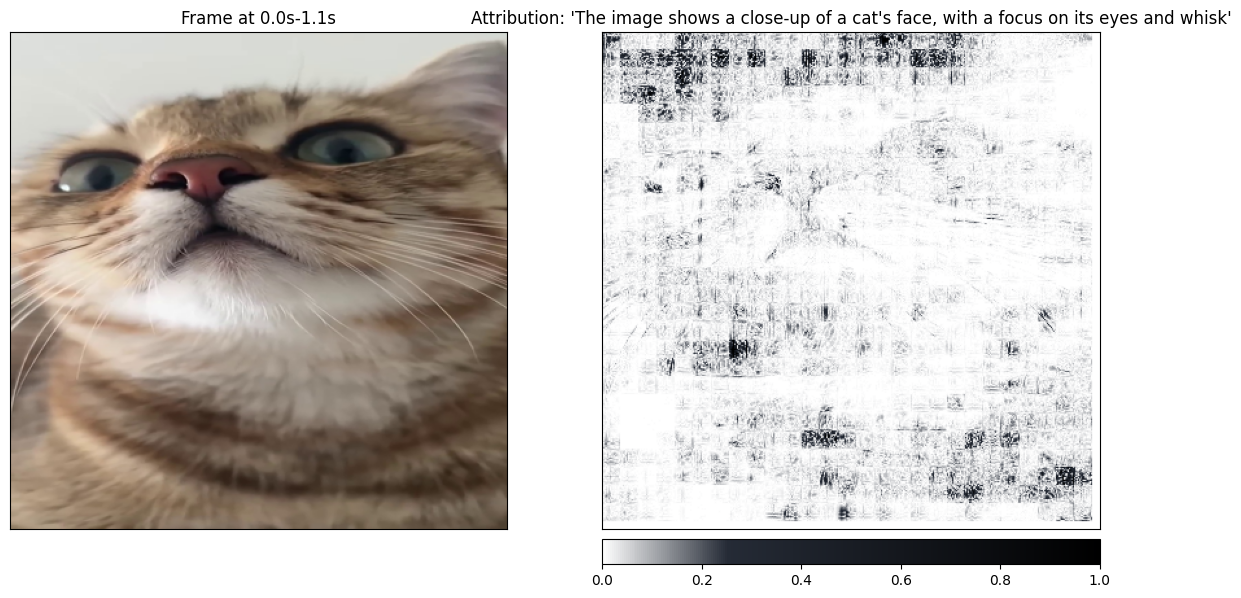

✓ Saved visualization to temporal_query_analysis/attribution_q3.png


<Figure size 640x480 with 0 Axes>

✓ Saved report to temporal_query_analysis/report_q3.txt

✓ TEMPORAL QUERY ANALYSIS COMPLETE
Results saved to: temporal_query_analysis/


Q: What is happening at 2 seconds?
Time: 2.0s - 2.0s
A: a cat is yawning
Confidence: 28.39%

Q: What occurs between 3 and 4 seconds?
Time: 3.0s - 4.0s
A: The cat is looking up.
Confidence: 40.36%

Q: What's at the beginning of the video?
Time: 0.0s - 1.1s
A: The image shows a close-up of a cat's face, with a focus on its eyes and whisk
Confidence: 37.92%


In [ ]:
# Define timestamp-specific questions
# The system automatically parses temporal references like "at 4 seconds", "first 10 seconds", etc.
temporal_questions = [
    "What is happening at 2 seconds?",
    "What occurs between 3 and 4 seconds?",
    "What's at the beginning of the video?",
]


query_results = temporal_query_vqa_interpret(
    video_path=video_path,
    temporal_questions=temporal_questions,
    model=model,
    processor=processor,
    fps_sample=4,  # Sample 1 frame per second
    aggregation_method='most_confident',  # Options: 'most_confident', 'consensus', 'average'
    show_visualizations=True,  # Show attribution heatmaps
    save_results=True,  # Save to 'temporal_query_analysis' folder
    include_text_attribution=True  # Set True to analyze question token importance
)

# Access results
for question, result in query_results.items():
    print(f"\nQ: {question}")
    print(f"Time: {result['temporal_info']['start_sec']:.1f}s - {result['temporal_info']['end_sec']:.1f}s")
    print(f"A: {result['prediction']}")
    print(f"Confidence: {result['confidence']:.2%}")

## Step 5: Text Attribution Analysis

Analyze which words in your question influence the prediction, and compare image vs text contribution.

In [ ]:
# Clear GPU memory before text attribution analysis
gc.collect()
torch.cuda.empty_cache()

print("✓ Memory cleared and ready for text attribution analysis")

✓ Memory cleared and ready for text attribution analysis


In [ ]:
# Upload your image
from google.colab import files

print("Click 'Choose Files' to upload an image...")
uploaded = files.upload()

if uploaded:
    image_path = list(uploaded.keys())[0]
    print(f"\n✓ Uploaded: {image_path}")
else:
    print("No file uploaded.")

Click 'Choose Files' to upload an image...


No file uploaded.


In [ ]:
question = [
    "When you see the number one, what color is it?",
    "Is the dog black or white"]
vqa_interpret(
    image_path=image_path,
    questions=question,
    model=model,
    processor=processor,
    show_top_k=10
)
# Run text attribution analysis
# mode: 'text' = text-only, 'joint' = image vs text, 'both' = both analyses
text_results = text_vqa_interpret(
    image_path=image_path,
    questions=question,
    model=model,
    processor=processor,
    mode='text',  # Compute both text and joint attributions
    n_steps=100,  # Number of IG steps (higher = more accurate but slower)
    show_visualizations=True
)

NameError: name 'image_path' is not defined

In [ ]:
# Upload your video
from google.colab import files

print("Click 'Choose Files' to upload a video...")
uploaded_video = files.upload()

if uploaded_video:
    video_path = list(uploaded_video.keys())[0]
    print(f"\n✓ Uploaded: {video_path}")
else:
    print("No video uploaded.")

Click 'Choose Files' to upload a video...


Saving 5 Second Countdown HD - AEdicas - Tutoriais em português (720p, h264, youtube).mp4 to 5 Second Countdown HD - AEdicas - Tutoriais em português (720p, h264, youtube).mp4

✓ Uploaded: 5 Second Countdown HD - AEdicas - Tutoriais em português (720p, h264, youtube).mp4


In [ ]:
# Define questions for video analysis
video_questions = [
      "What is happening?",
      "What object is visible?"
  ]

  # Run temporal analysis
  # Parameters:
  # - fps_sample: How many frames per second to sample (1 = 1 frame/sec, 0.5 = 1 frame/2 sec)
  # - max_frames: Maximum frames to process (None = all sampled frames)
  # - show_frame_visualizations: Show heatmap for each frame (slow, use False for long videos)
  # - show_timeline: Show timeline graphs of predictions over time
  # - save_results: Save reports and visualizations to files
  # - include_text_attribution: Compute image vs text attribution per frame

results = temporal_vqa_interpret(
      video_path=video_path,
      questions=video_questions,
      model=model,
      processor=processor,
      fps_sample=1,  # Sample 1 frame per second
      max_frames=20,  # Process max 20 frames (adjust based on video length)
      show_frame_visualizations=True,  # Show image heatmap + text attribution per frame
      show_timeline=True,  # Show timeline graphs
      save_results=True,  # Save reports to 'video_analysis' folder
      include_text_attribution=True  # Enable text vs image attribution analysis
  )



TEMPORAL VIDEO ANALYSIS
Video: 18585469.mp4
Questions: 2
Sample Rate: 1 FPS
Text Attribution: Enabled

Video FPS: 30.00
Sampling every 30 frames (1 FPS)


Extracting frames: 20it [00:00, 28.03it/s]


✓ Extracted 20 frames to video_analysis/frames/

Question 1/2: What is happening?



Processing frames:   0%|          | 0/20 [00:09<?, ?it/s]


AttributeError: 'LlavaOnevisionForConditionalGeneration' object has no attribute 'language_model'

In [ ]:
conditional_questions = [
    "When you see birds, how many do you see?"
]
# Run conditional query analysis
# The LLM will:
# - Parse each question to understand the condition and the actual question
# - For conditional questions: scan all frames, find matches, then answer
# - For timestamp/simple questions: use appropriate frame selection

# Parameters:
# - fps_sample: How many frames per second to sample (1 = 1 frame/sec)
# - confidence_threshold: Minimum confidence for frame matching (0.5 = balanced)
#     Higher (0.6-0.7) = stricter matching, fewer frames
#     Lower (0.3-0.4) = more lenient, more frames
# - aggregation_method: How to combine multi-frame results
#     'most_confident': Use frame with highest confidence (default)
#     'consensus': Use most common prediction (best for many matches)
#     'average': Average attributions and confidences
# - show_visualizations: Show attribution heatmaps
# - save_results: Save detailed reports

conditional_results = conditional_query_vqa_interpret(
    video_path=video_path,
    questions=conditional_questions,
    model=model,
    processor=processor,
    fps_sample=1,  # Sample 1 frame per second
    confidence_threshold=0.8,  # Balanced threshold (0.3-0.7 range)
    aggregation_method='average',  # Options: 'most_confident', 'consensus', 'average'
    show_visualizations=True,
    save_results=True,  # Saves to 'conditional_query_analysis' folder
    include_text_attribution=True
)

# Display summary of results
print("\n" + "="*70)
print("CONDITIONAL QUERY RESULTS SUMMARY")
print("="*70)

for question, result in conditional_results.items():
    print(f"\n📝 Q: {question}")

    if 'error' in result:
        print(f"   ❌ Error: {result['error']}")
        continue

    # Show how the LLM parsed the question
    parsed = result['query_info']['parsed']
    print(f"   🔍 Type: {parsed['type']}")

    if parsed['type'] == 'conditional':
        print(f"Condition: {parsed['frame_condition']}")
        print(f"Frames matched: {result['query_info']['num_matching_frames']}/{result['query_info']['total_frames']}")
        print(f"Frame indices: {result['query_info']['frame_indices']}")

    # Show the answer
    print(f"Answer: {result['prediction']}")
    print(f"Confidence: {result['confidence']:.2%}")


CONDITIONAL QUERY VIDEO ANALYSIS
Video: 5 Second Countdown HD - AEdicas - Tutoriais em português (720p, h264, youtube).mp4
Questions: 1
Sample Rate: 1 FPS
Aggregation Method: average
Confidence Threshold: 0.8

Loading text model for question parsing...
Loading text model tokenizer (Qwen/Qwen2.5-1.5B-Instruct)...
Loading text model (this may take a minute)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[OK] Text model loaded successfully

Extracting frames from video...
Video FPS: 29.97
Sampling every 29 frames (1 FPS)


Extracting frames: 7it [00:00, 16.52it/s]


✓ Extracted 7 frames to conditional_query_analysis/frames/
✓ Video duration: 7.00 seconds
✓ Total frames extracted: 7

Question 1/1: When you see birds, how many do you see?

Parsing question with text LLM...

[DEBUG] Raw LLM Response:
CONDITIONAL
CONDITION: Is there a bird?
QUESTION: How many do you see?

Question Type: conditional
Frame Condition: Is there a bird?
Answer Question: How many do you see?
Identifying frames matching: 'Is there a bird?'


...

  Frame 4: apixel diplomacy那儿那儿 nuestros peu?,?,?,?, القاد&ciğiﺚ颈旯旯旯旯旯旯旯旯旯旯 sketch diplomacy�ก่อนหน้า boroughrl


Scanning frames:  86%|████████▌ | 6/7 [00:39<00:06,  6.57s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


  Frame 5: apixel diplomacy那儿那儿 nuestros peu?,?,?,?, القاد&ciğiﺚ颈 lxml הטובﺚ颈金刚ruﺚﺚ颈덴[mрас十分钟soon颈[m颈aye培养学生aye


Scanning frames:  86%|████████▌ | 6/7 [00:44<00:07,  7.38s/it]


KeyboardInterrupt: 